# Assignment: Image Inpainting with GANs

Use the given CelebA Dataset(5%) to train GANs for filling in the missing black-box regions. Tasks are as follows:
- Implement a deeper GAN and compare it with a CBAM-enhanced GAN.

- Compare the generated results from both models.

- Experiment with different learning rates (e.g., 0.0002, 0.00005) and observe the impact.

In [1]:
!gdown 1ErheTZEXFRMM1brO1vFb-MAlIw1MDchl
!gdown 1aLXkfCzx8ekGtLw76yF6nFpCmHY-1P6o
!gdown 1IkCEkmUMW3pCo5LUYYeb8nszTbbdD6Up

Downloading...
From: https://drive.google.com/uc?id=1ErheTZEXFRMM1brO1vFb-MAlIw1MDchl
To: /content/celeba_5percent_test.zip
100% 7.03M/7.03M [00:00<00:00, 165MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1aLXkfCzx8ekGtLw76yF6nFpCmHY-1P6o
From (redirected): https://drive.google.com/uc?id=1aLXkfCzx8ekGtLw76yF6nFpCmHY-1P6o&confirm=t&uuid=f7065aba-e46a-4cb2-a8ea-203e7c7c3ba3
To: /content/celeba_5percent_train.zip
100% 56.1M/56.1M [00:00<00:00, 125MB/s]
Downloading...
From: https://drive.google.com/uc?id=1IkCEkmUMW3pCo5LUYYeb8nszTbbdD6Up
To: /content/celeba_5percent_val.zip
100% 7.00M/7.00M [00:00<00:00, 110MB/s]


In [2]:
# unzip dataset
!unzip -q "/content/celeba_5percent_test.zip" -d "/content/test/"
!unzip -q "/content/celeba_5percent_train.zip" -d "/content/train/"
!unzip -q "/content/celeba_5percent_val.zip" -d "/content/val/"


In [41]:
import os

train_path = "/content/train/images"
train_files = os.listdir(train_path)
print(f"A total of {len(train_files)} images")
print("Image Name:", sorted(train_files)[:5])

val_path = "/content/val/images"
val_files = os.listdir(val_path)
print(f"A total of {len(val_files)} images")
print("Image Name:", sorted(val_files)[:5])

test_path = "/content/test/images"
test_files = os.listdir(test_path)
print(f"A total of {len(test_files)} images")
print("Image Name:", sorted(test_files)[:5])

A total of 8103 images
Image Name: ['000018.jpg', '000068.jpg', '000090.jpg', '000145.jpg', '000154.jpg']
A total of 1013 images
Image Name: ['000007.jpg', '000226.jpg', '000551.jpg', '000558.jpg', '000680.jpg']
A total of 1013 images
Image Name: ['000080.jpg', '000206.jpg', '000264.jpg', '000271.jpg', '000346.jpg']


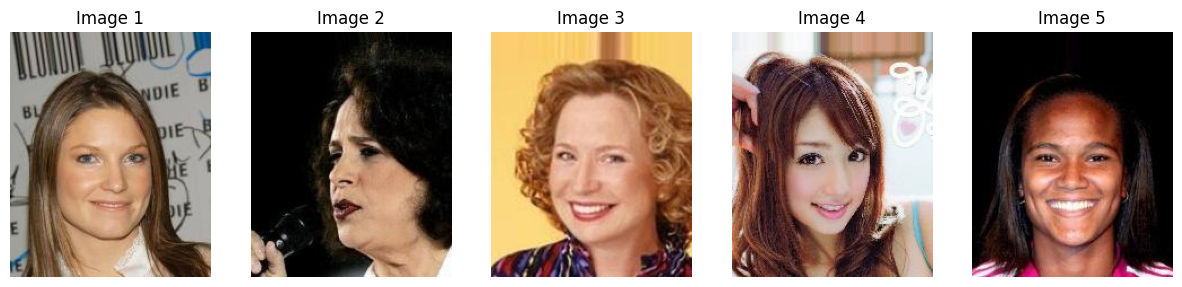

In [43]:
import matplotlib.pyplot as plt
import cv2
import random

random_images = random.sample(val_files, 5)
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i, img_file in enumerate(random_images):
    img = cv2.imread(os.path.join(val_path, img_file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(f"Image {i+1}")
    axes[i].axis("off")
plt.show()


In [28]:
# Answer your code here
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import numpy as np

# from PIL import Image

## Implement a deeper GAN and compare it with a CBAM-enhanced GAN.

### Deeper GAN

In [17]:
import shutil

# Define the root directories
root_dirs = ["/content/test", "/content/train", "/content/val"]

for root_dir in root_dirs:
    # Create a subdirectory named 'images'
    images_dir = os.path.join(root_dir, "images")
    os.makedirs(images_dir, exist_ok=True)

    # Move all the files from the root to the subdirectory
    for file_name in os.listdir(root_dir):
        file_path = os.path.join(root_dir, file_name)
        if os.path.isfile(file_path):
            shutil.move(file_path, images_dir)

In [23]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),  # Resize images to a consistent size
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalize for 3 channels
])

# Create the dataset
test_dataset = ImageFolder(root='/content/test', transform=transform)
train_dataset = ImageFolder(root='/content/train', transform=transform)
val_dataset = ImageFolder(root='/content/val', transform=transform)
# Create the DataLoader
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=True)

In [31]:
class Generator(nn.Module):
    def __init__(self, input_dim=100, output_dim=12288):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(128, 256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, output_dim),
            nn.Tanh()  # เอาต์พุตอยู่ในช่วง [-1, 1]
        )

    def forward(self, x):
        return self.net(x)

In [32]:
class Discriminator(nn.Module):
    def __init__(self, input_dim=12288):
        super(Discriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Linear(128, 1),
            nn.Sigmoid()  # เอาต์พุตเป็นความน่าจะเป็นระหว่าง [0,1]
        )

    def forward(self, x):
        return self.net(x)

In [33]:
# เริ่มต้น Generator และ Discriminator
G = Generator()
D = Discriminator()

# ใช้ GPU ถ้ามี
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
G.to(device)
D.to(device)

# ฟังก์ชันค่าเสียหาย
criterion = nn.BCELoss()

# ตัวปรับแต่ง
lr = 0.0002
G_optimizer = optim.Adam(G.parameters(), lr=lr)
D_optimizer = optim.Adam(D.parameters(), lr=lr)


Epoch [1/10]  D_loss: 0.8924  G_loss: 0.6169


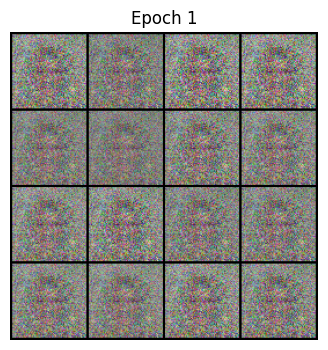

Epoch [2/10]  D_loss: 1.2572  G_loss: 0.6029
Epoch [3/10]  D_loss: 1.0049  G_loss: 0.5794
Epoch [4/10]  D_loss: 1.0640  G_loss: 0.6297
Epoch [5/10]  D_loss: 1.0918  G_loss: 0.5767
Epoch [6/10]  D_loss: 1.0386  G_loss: 0.6021
Epoch [7/10]  D_loss: 1.0943  G_loss: 0.6622
Epoch [8/10]  D_loss: 0.9959  G_loss: 0.5875
Epoch [9/10]  D_loss: 1.1415  G_loss: 0.6175
Epoch [10/10]  D_loss: 1.1648  G_loss: 0.6151


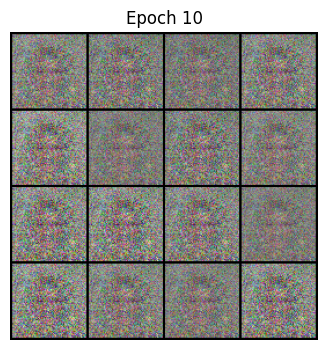

In [95]:
# พารามิเตอร์การฝึก
num_epochs = 10
latent_dim = 100
sample_interval = 10  # บันทึกตัวอย่างทุก 10 epoch

# รายการเก็บค่าเสียหายสำหรับการวาดกราฟ
G_losses = []
D_losses = []

for epoch in range(1, num_epochs+1):
    for batch_idx, (real_data, _) in enumerate(train_loader):
        real_data = real_data.view(-1, 12288).to(device) #Change the size to 12288

        # ป้ายกำกับสำหรับข้อมูลจริงและปลอม
        real_labels = torch.ones(real_data.size(0), 1).to(device)
        fake_labels = torch.zeros(real_data.size(0), 1).to(device)

        ## ฝึก Discriminator
        D_optimizer.zero_grad()

        # ข้อมูลจริง
        outputs = D(real_data)
        D_real_loss = criterion(outputs, real_labels)

        # ข้อมูลปลอม
        z = torch.randn(real_data.size(0), latent_dim).to(device)
        fake_data = G(z)
        outputs = D(fake_data.detach())  # Detach เพื่อไม่ให้ฝึก G บนป้ายกำกับเหล่านี้
        D_fake_loss = criterion(outputs, fake_labels)

        # ค่าเสียหายรวมของ Discriminator
        D_loss = D_real_loss + D_fake_loss
        D_loss.backward()
        D_optimizer.step()

        ## ฝึก Generator
        G_optimizer.zero_grad()

        # สร้างข้อมูลปลอมและพยายามหลอก Discriminator
        z = torch.randn(real_data.size(0), latent_dim).to(device)
        fake_data = G(z)
        outputs = D(fake_data)
        G_loss = criterion(outputs, real_labels)  # เราต้องการให้ D เชื่อว่าข้อมูลปลอมเป็นจริง

        G_loss.backward()
        G_optimizer.step()

        # บันทึกค่าความเสียหายสำหรับการวาดกราฟ
        G_losses.append(G_loss.item())
        D_losses.append(D_loss.item())

    # แสดงความคืบหน้า
    print(f"Epoch [{epoch}/{num_epochs}]  D_loss: {D_loss.item():.4f}  G_loss: {G_loss.item():.4f}")

    # บันทึกรูปตัวอย่าง
    if epoch % sample_interval == 0 or epoch == 1:
        with torch.no_grad():
            z = torch.randn(16, latent_dim).to(device)
            sample = G(z).cpu().view(-1, 3, 64, 64) #Changed view
            grid = torchvision.utils.make_grid(sample, nrow=4, normalize=True)
            np_grid = grid.numpy()
            plt.figure(figsize=(4,4))
            plt.imshow(np.transpose(np_grid, (1,2,0)))
            plt.title(f'Epoch {epoch}')
            plt.axis('off')
            plt.show()


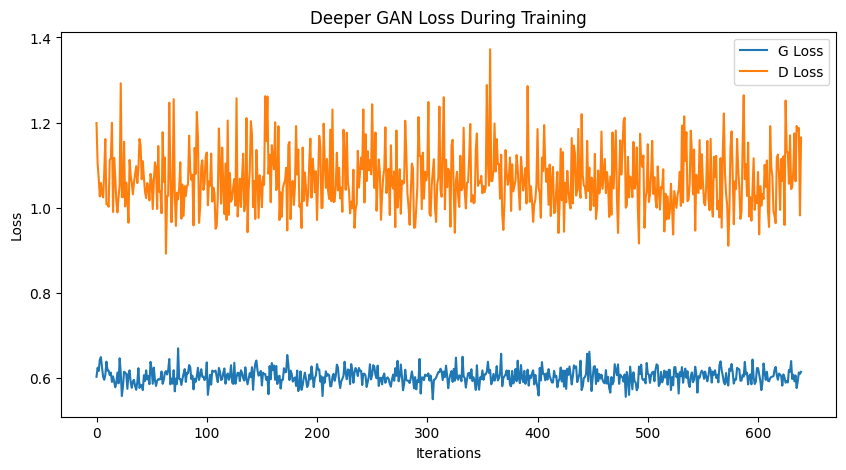

In [96]:
# วาดกราฟ loss
plt.figure(figsize=(10,5))
plt.title("Deeper GAN Loss During Training")
plt.plot(G_losses, label="G Loss")
plt.plot(D_losses, label="D Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

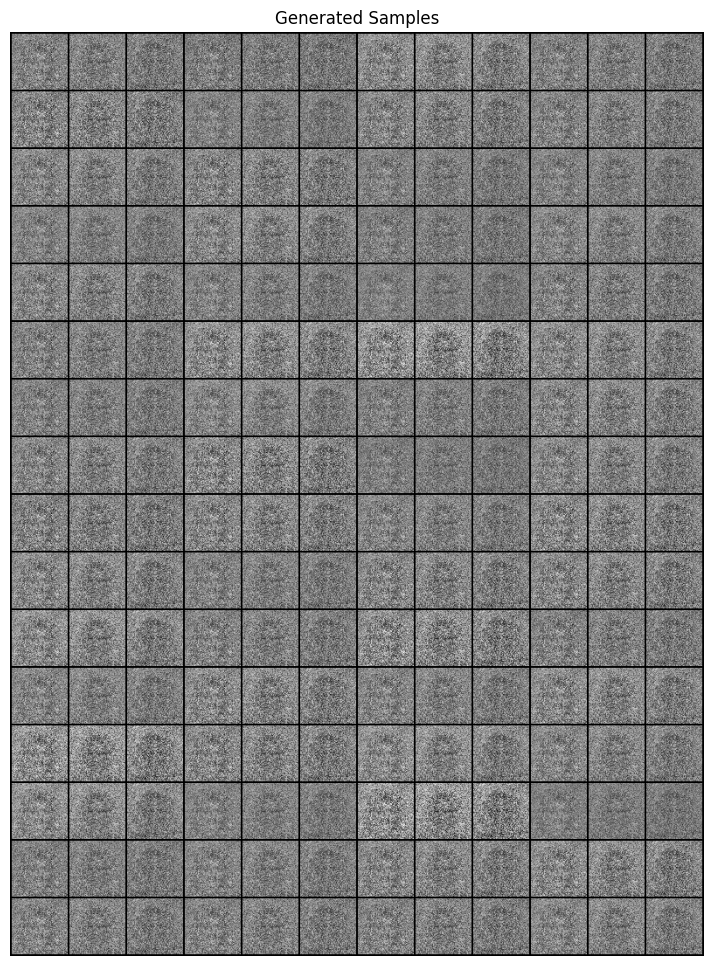

In [100]:
# สร้างตัวอย่างใหม่
with torch.no_grad():
    z = torch.randn(64, latent_dim).to(device)
    generated_samples = G(z).cpu().view(-1, 1, 64, 64)
    grid = torchvision.utils.make_grid(generated_samples, nrow=12, normalize=True)
    np_grid = grid.numpy()
    plt.figure(figsize=(12,12))
    plt.imshow(np.transpose(np_grid, (1,2,0)))
    plt.title("Generated Samples")
    plt.axis('off')
    plt.show()


### CBAM

In [83]:
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(in_channels // reduction, in_channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.size()
        avg_out = self.fc(self.avg_pool(x).view(b, c))
        max_out = self.fc(self.max_pool(x).view(b, c))
        out = self.sigmoid(avg_out + max_out).view(b, c, 1, 1)
        return x * out

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.sigmoid(self.conv(out))
        return x * out

In [84]:
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.channel_att = ChannelAttention(channels, reduction)
        self.spatial_att = SpatialAttention(kernel_size)

    def forward(self, x):
        x = self.channel_att(x)
        x = self.spatial_att(x)
        return x

In [85]:
class Generator_CBAM(nn.Module):
    def __init__(self, input_dim=100, output_dim=3, img_size=64, channels=64):
        super(Generator_CBAM, self).__init__()
        self.init_size = img_size // 4  # ขนาดของ feature map เริ่มต้น
        self.fc = nn.Linear(input_dim, channels * self.init_size**2)

        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(channels),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(channels, channels//2, 3, stride=1, padding=1),
            nn.BatchNorm2d(channels//2),
            nn.LeakyReLU(0.2, inplace=True),
            CBAM(channels//2),  # ใส่ CBAM
            nn.Upsample(scale_factor=2),
            nn.Conv2d(channels//2, output_dim, 3, stride=1, padding=1),
            nn.Tanh()  # ค่าอยู่ในช่วง [-1,1]
        )

    def forward(self, z):
        out = self.fc(z)
        out = out.view(out.shape[0], -1, self.init_size, self.init_size)
        return self.conv_blocks(out)

class Discriminator_CBAM(nn.Module):
    def __init__(self, input_dim=3, img_size=64, channels=64):
        super(Discriminator_CBAM, self).__init__()
        self.conv_blocks = nn.Sequential(
            nn.Conv2d(input_dim, channels, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            CBAM(channels),  # เพิ่ม CBAM หลังจาก Conv
            nn.Dropout(0.3),

            nn.Conv2d(channels, channels * 2, 3, stride=2, padding=1),
            nn.BatchNorm2d(channels * 2),
            nn.LeakyReLU(0.2, inplace=True),
            CBAM(channels * 2),  # CBAM อีกครั้ง
            nn.Dropout(0.3),

            nn.Conv2d(channels * 2, channels * 4, 3, stride=2, padding=1),
            nn.BatchNorm2d(channels * 4),
            nn.LeakyReLU(0.2, inplace=True),
            CBAM(channels * 4),  # CBAM ซ้ำ
            nn.Dropout(0.3),
        )

        self.fc = nn.Sequential(
            nn.Linear(channels * 4 * (img_size // 8) * (img_size // 8), 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        out = self.conv_blocks(x)
        out = out.view(out.size(0), -1)
        return self.fc(out)


#### Learning rate = 2e-4

Epoch [1/10]  D_loss: 0.0355  G_loss: 4.5231


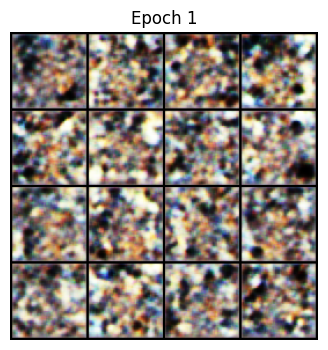

Epoch [2/10]  D_loss: 0.1619  G_loss: 6.6872
Epoch [3/10]  D_loss: 0.4887  G_loss: 3.1877
Epoch [4/10]  D_loss: 0.3475  G_loss: 2.9095
Epoch [5/10]  D_loss: 0.1501  G_loss: 3.9008


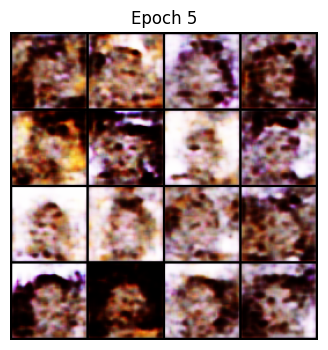

Epoch [6/10]  D_loss: 0.5817  G_loss: 3.1975
Epoch [7/10]  D_loss: 0.4606  G_loss: 3.0435
Epoch [8/10]  D_loss: 0.3534  G_loss: 2.7111
Epoch [9/10]  D_loss: 0.1621  G_loss: 3.5983
Epoch [10/10]  D_loss: 0.1696  G_loss: 4.1706


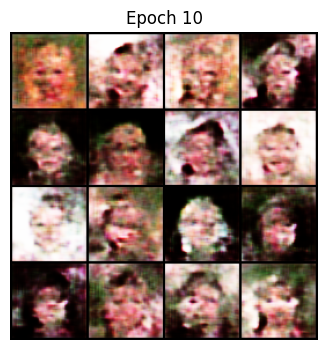

In [86]:
# เริ่มต้น Generator และ Discriminator
G_CBAM = Generator_CBAM()
D_CBAM = Discriminator_CBAM()

# ใช้ GPU ถ้ามี
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
G_CBAM.to(device)
D_CBAM.to(device)

# ฟังก์ชันค่าเสียหาย
criterion = nn.BCELoss()

# ตัวปรับแต่ง
lr = 0.0002
G_optimizer = optim.Adam(G_CBAM.parameters(), lr=lr)
D_optimizer = optim.Adam(D_CBAM.parameters(), lr=lr)

# พารามิเตอร์การฝึก
num_epochs = 10
latent_dim = 100
sample_interval = 5  # บันทึกตัวอย่างทุก 10 epoch

# รายการเก็บค่าเสียหายสำหรับการวาดกราฟ
G_CBAM_losses = []
D_CBAM_losses = []

for epoch in range(1, num_epochs+1):
    for batch_idx, (real_data, _) in enumerate(train_loader):
        real_data = real_data.to(device) #Add this line to pass to GPU

        # ป้ายกำกับสำหรับข้อมูลจริงและปลอม
        real_labels = torch.ones(real_data.size(0), 1).to(device)
        fake_labels = torch.zeros(real_data.size(0), 1).to(device)

        ## ฝึก Discriminator
        D_optimizer.zero_grad()

        # ข้อมูลจริง
        outputs = D_CBAM(real_data)
        D_real_loss = criterion(outputs, real_labels)

        # ข้อมูลปลอม
        z = torch.randn(real_data.size(0), latent_dim).to(device)
        fake_data = G_CBAM(z)
        outputs = D_CBAM(fake_data.detach())  # Detach เพื่อไม่ให้ฝึก G บนป้ายกำกับเหล่านี้
        D_fake_loss = criterion(outputs, fake_labels)

        # ค่าเสียหายรวมของ Discriminator
        D_loss = D_real_loss + D_fake_loss
        D_loss.backward()
        D_optimizer.step()

        ## ฝึก Generator
        G_optimizer.zero_grad()

        # สร้างข้อมูลปลอมและพยายามหลอก Discriminator
        z = torch.randn(real_data.size(0), latent_dim).to(device)
        fake_data = G_CBAM(z)
        outputs = D_CBAM(fake_data)
        G_loss = criterion(outputs, real_labels)  # เราต้องการให้ D เชื่อว่าข้อมูลปลอมเป็นจริง

        G_loss.backward()
        G_optimizer.step()

        # บันทึกค่าความเสียหายสำหรับการวาดกราฟ
        G_CBAM_losses.append(G_loss.item())
        D_CBAM_losses.append(D_loss.item())

    # แสดงความคืบหน้า
    print(f"Epoch [{epoch}/{num_epochs}]  D_loss: {D_loss.item():.4f}  G_loss: {G_loss.item():.4f}")

    # บันทึกรูปตัวอย่าง
    if epoch % sample_interval == 0 or epoch == 1:
        with torch.no_grad():
            z = torch.randn(16, latent_dim).to(device)
            sample = G_CBAM(z).cpu().view(-1, 3, 64, 64)
            grid = torchvision.utils.make_grid(sample, nrow=4, normalize=True)
            np_grid = grid.numpy()
            plt.figure(figsize=(4,4))
            plt.imshow(np.transpose(np_grid, (1,2,0)))
            plt.title(f'Epoch {epoch}')
            plt.axis('off')
            plt.show()

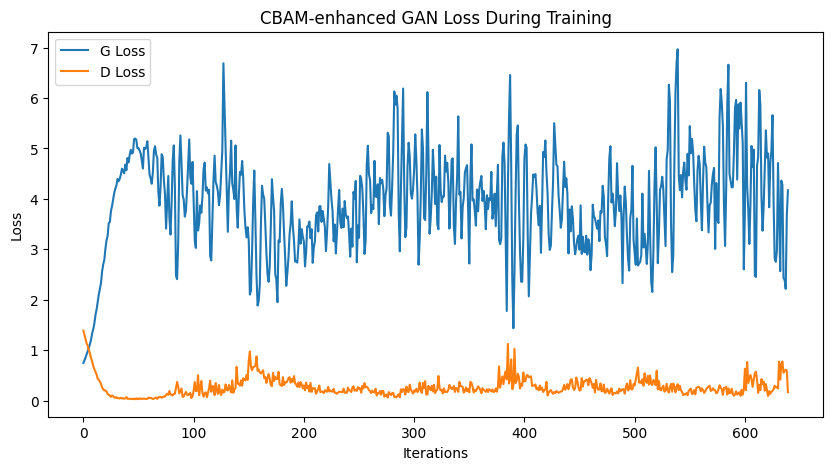

In [87]:
# วาดกราฟ loss
plt.figure(figsize=(10,5))
plt.title("CBAM-enhanced GAN Loss During Training")
plt.plot(G_CBAM_losses, label="G Loss")
plt.plot(D_CBAM_losses, label="D Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

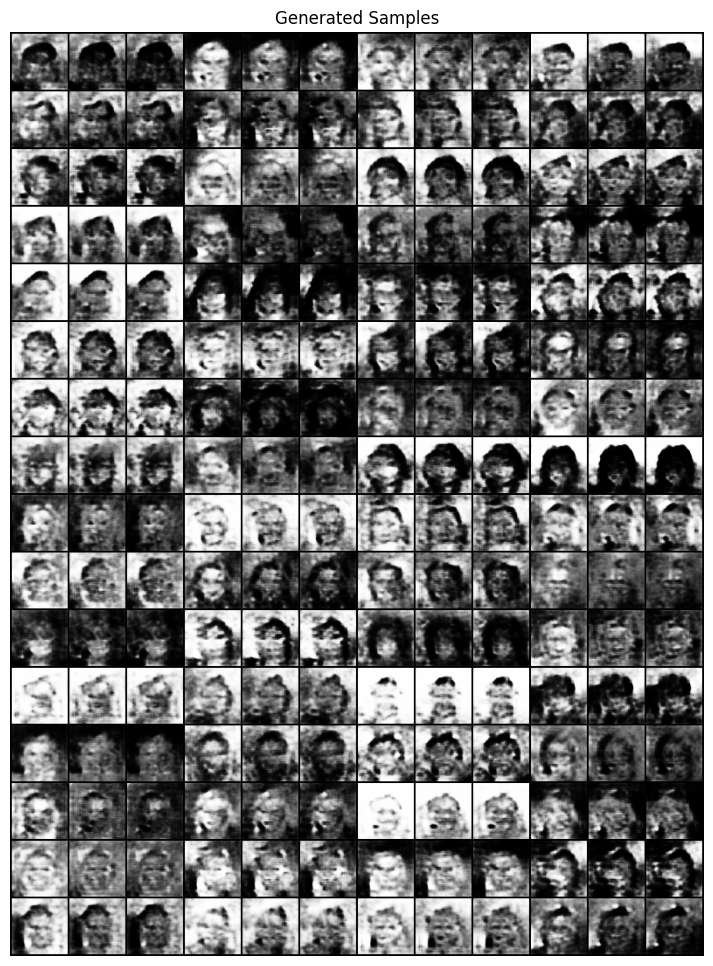

In [88]:
# สร้างตัวอย่างใหม่
with torch.no_grad():
    z = torch.randn(64, latent_dim).to(device)
    generated_samples = G_CBAM(z).cpu().view(-1, 1, 64, 64)
    grid = torchvision.utils.make_grid(generated_samples, nrow=12, normalize=True)
    np_grid = grid.numpy()
    plt.figure(figsize=(12,12))
    plt.imshow(np.transpose(np_grid, (1,2,0)))
    plt.title("Generated Samples")
    plt.axis('off')
    plt.show()


### Compare the generated results from both models.

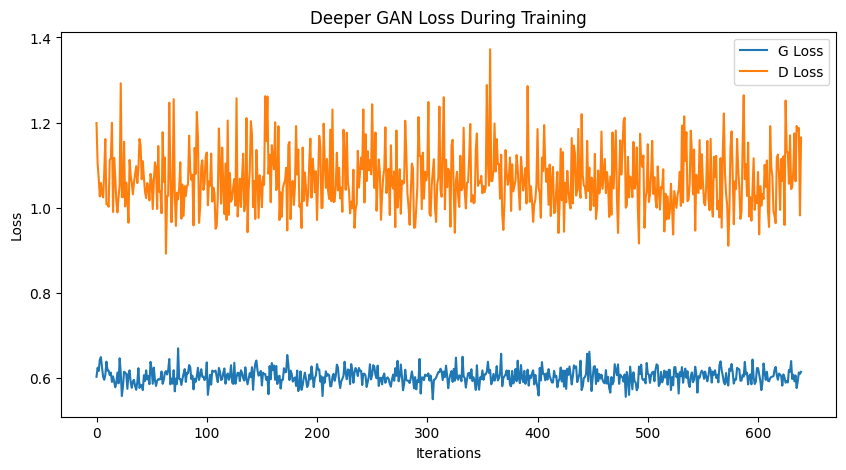

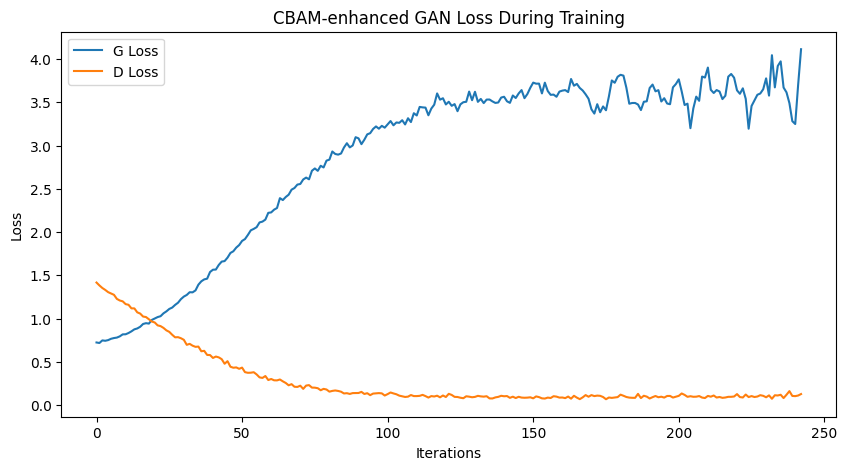

In [97]:
# วาดกราฟ loss
plt.figure(figsize=(10,5))
plt.title("Deeper GAN Loss During Training")
plt.plot(G_losses, label="G Loss")
plt.plot(D_losses, label="D Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

# วาดกราฟ loss
plt.figure(figsize=(10,5))
plt.title("CBAM-enhanced GAN Loss During Training")
plt.plot(G_CBAM_losses, label="G Loss")
plt.plot(D_CBAM_losses, label="D Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

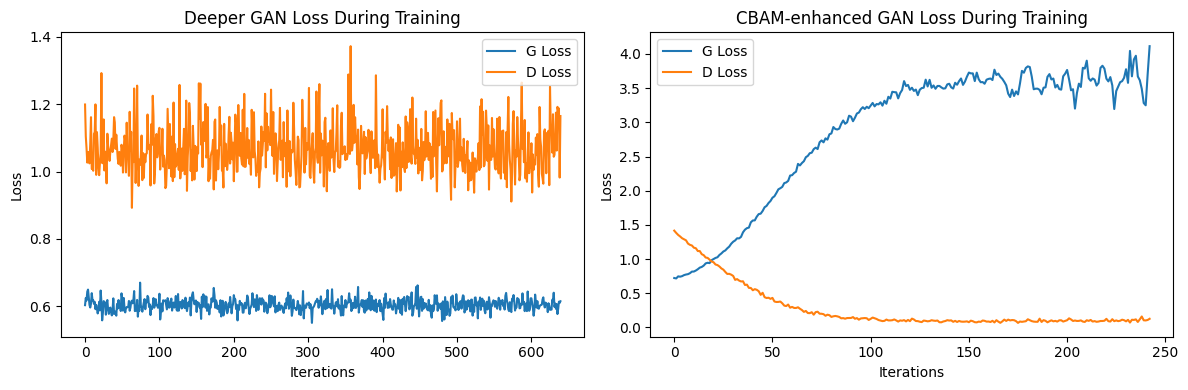

In [98]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Plotting losses for Deeper GAN
axs[0].set_title("Deeper GAN Loss During Training")
axs[0].plot(G_losses, label="G Loss")
axs[0].plot(D_losses, label="D Loss")
axs[0].set_xlabel("Iterations")
axs[0].set_ylabel("Loss")
axs[0].legend()

# Plotting losses for CBAM-enhanced GAN
axs[1].set_title("CBAM-enhanced GAN Loss During Training")
axs[1].plot(G_CBAM_losses, label="G Loss")
axs[1].plot(D_CBAM_losses, label="D Loss")
axs[1].set_xlabel("Iterations")
axs[1].set_ylabel("Loss")
axs[1].legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

**Ans.** The Deeper GAN (left) has a stable but low G Loss and highly fluctuating D Loss, indicating unstable training. In contrast, the CBAM GAN (right) shows a steadily increasing G Loss and a stabilizing D Loss, suggesting a more balanced and structured learning process.



---

Deeper GAN (ซ้าย) มี G Loss ที่คงที่แต่ต่ำ และ D Loss ผันผวนมาก แสดงถึงการฝึกที่ไม่เสถียร ส่วน CBAM GAN (ขวา) มี G Loss เพิ่มขึ้นต่อเนื่อง และ D Loss ค่อยๆ คงที่ ทำให้การเรียนรู้สมดุลและมีโครงสร้างดีกว่า

### Experiment with different learning rates (e.g., 0.0002, 0.00005) and observe the impact.

#### Learning rate = 5e-5

**ใช้ CBAM GAN**

Epoch [1/10]  D_loss: 0.4188  G_loss: 1.7651


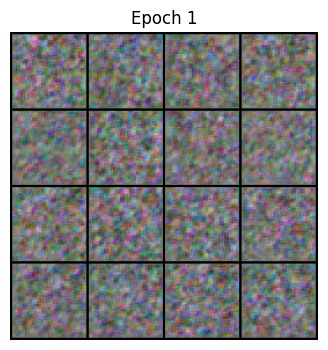

Epoch [2/10]  D_loss: 0.1217  G_loss: 3.1665
Epoch [3/10]  D_loss: 0.2406  G_loss: 3.0610
Epoch [4/10]  D_loss: 0.1779  G_loss: 3.0039
Epoch [5/10]  D_loss: 0.1819  G_loss: 3.0533


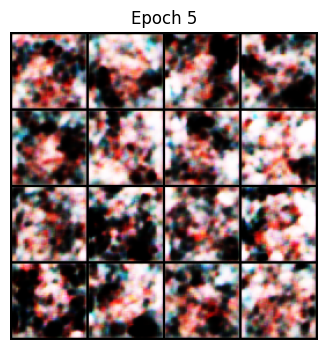

Epoch [6/10]  D_loss: 0.2243  G_loss: 3.6677
Epoch [7/10]  D_loss: 0.1035  G_loss: 4.5893
Epoch [8/10]  D_loss: 0.0732  G_loss: 5.4251
Epoch [9/10]  D_loss: 0.2139  G_loss: 4.0656
Epoch [10/10]  D_loss: 0.0264  G_loss: 6.7960


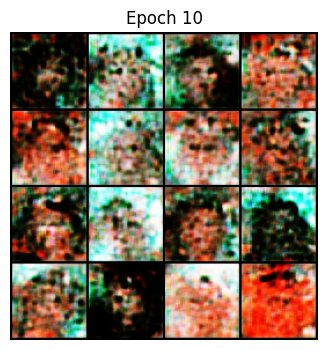

In [92]:
# เริ่มต้น Generator และ Discriminator
G_CBAM = Generator_CBAM()
D_CBAM = Discriminator_CBAM()

# ใช้ GPU ถ้ามี
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
G_CBAM.to(device)
D_CBAM.to(device)

# ฟังก์ชันค่าเสียหาย
criterion = nn.BCELoss()

# ตัวปรับแต่ง
lr = 0.00005 # ปรับเป็น 5e-5
G_optimizer = optim.Adam(G_CBAM.parameters(), lr=lr)
D_optimizer = optim.Adam(D_CBAM.parameters(), lr=lr)

# พารามิเตอร์การฝึก
num_epochs = 10
latent_dim = 100
sample_interval = 5  # บันทึกตัวอย่างทุก 10 epoch

# รายการเก็บค่าเสียหายสำหรับการวาดกราฟ
G_CBAM_losses_lr = []
D_CBAM_losses_lr = []

for epoch in range(1, num_epochs+1):
    for batch_idx, (real_data, _) in enumerate(train_loader):
        # real_data = real_data.view(-1, 12288).to(device) #Remove this line
        real_data = real_data.to(device) #Add this line to pass to GPU

        # ป้ายกำกับสำหรับข้อมูลจริงและปลอม
        real_labels = torch.ones(real_data.size(0), 1).to(device)
        fake_labels = torch.zeros(real_data.size(0), 1).to(device)

        ## ฝึก Discriminator
        D_optimizer.zero_grad()

        # ข้อมูลจริง
        outputs = D_CBAM(real_data)
        D_real_loss = criterion(outputs, real_labels)

        # ข้อมูลปลอม
        z = torch.randn(real_data.size(0), latent_dim).to(device)
        fake_data = G_CBAM(z)
        outputs = D_CBAM(fake_data.detach())  # Detach เพื่อไม่ให้ฝึก G บนป้ายกำกับเหล่านี้
        D_fake_loss = criterion(outputs, fake_labels)

        # ค่าเสียหายรวมของ Discriminator
        D_loss = D_real_loss + D_fake_loss
        D_loss.backward()
        D_optimizer.step()

        ## ฝึก Generator
        G_optimizer.zero_grad()

        # สร้างข้อมูลปลอมและพยายามหลอก Discriminator
        z = torch.randn(real_data.size(0), latent_dim).to(device)
        fake_data = G_CBAM(z)
        outputs = D_CBAM(fake_data)
        G_loss = criterion(outputs, real_labels)  # เราต้องการให้ D เชื่อว่าข้อมูลปลอมเป็นจริง

        G_loss.backward()
        G_optimizer.step()

        # บันทึกค่าความเสียหายสำหรับการวาดกราฟ
        G_CBAM_losses_lr.append(G_loss.item())
        D_CBAM_losses_lr.append(D_loss.item())

    # แสดงความคืบหน้า
    print(f"Epoch [{epoch}/{num_epochs}]  D_loss: {D_loss.item():.4f}  G_loss: {G_loss.item():.4f}")

    # บันทึกรูปตัวอย่าง
    if epoch % sample_interval == 0 or epoch == 1:
        with torch.no_grad():
            z = torch.randn(16, latent_dim).to(device)
            sample = G_CBAM(z).cpu().view(-1, 3, 64, 64) #Changed to view the data with the correct shape
            grid = torchvision.utils.make_grid(sample, nrow=4, normalize=True)
            np_grid = grid.numpy()
            plt.figure(figsize=(4,4))
            plt.imshow(np.transpose(np_grid, (1,2,0)))
            plt.title(f'Epoch {epoch}')
            plt.axis('off')
            plt.show()

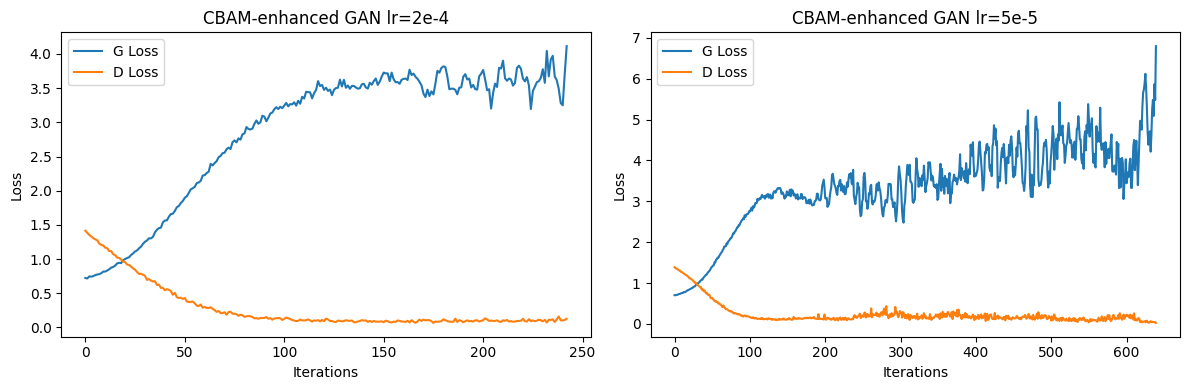

In [99]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Plotting losses for Deeper GAN
axs[0].set_title("CBAM-enhanced GAN lr=2e-4")
axs[0].plot(G_CBAM_losses, label="G Loss")
axs[0].plot(D_CBAM_losses, label="D Loss")
axs[0].set_xlabel("Iterations")
axs[0].set_ylabel("Loss")
axs[0].legend()

# Plotting losses for CBAM-enhanced GAN
axs[1].set_title("CBAM-enhanced GAN lr=5e-5")
axs[1].plot(G_CBAM_losses_lr, label="G Loss")
axs[1].plot(D_CBAM_losses_lr, label="D Loss")
axs[1].set_xlabel("Iterations")
axs[1].set_ylabel("Loss")
axs[1].legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

**Ans.** Left (lr = 2e-4) The generator loss (G Loss) increases smoothly, while the discriminator loss (D Loss) decreases and stabilizes quickly. Training appears more stable.
Right (lr = 5e-5) The generator loss fluctuates more, and training takes longer to stabilize. The lower learning rate results in slower but potentially more fine-tuned learning.



---


ซ้าย (lr = 2e-4) การสูญเสียของ Generator (G Loss) เพิ่มขึ้นอย่างราบรื่น ในขณะที่การสูญเสียตัวจำแนก (D Loss) ลดลงและคงที่อย่างรวดเร็ว การฝึกอบรมดูมีเสถียรภาพมากขึ้น ขวา (lr = 5e-5) การสูญเสีย Generator มีความผันผวนมากขึ้น และการฝึกจะใช้เวลานานกว่าในการทรงตัว อัตราการเรียนรู้ที่ต่ำกว่าส่งผลให้การเรียนรู้ช้าลงแต่อาจมีการปรับแต่งมากขึ้น